# Gradient Analysis Experiments

This notebook analyzes gradient flow in neural networks with different initialization strategies.

**Experiments:**
1. Single architecture gradient analysis
2. Comparison across initialization strategies
3. Deep network (100+ layers) analysis
4. Zero gradient and dead neuron statistics

In [45]:
# Setup
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from rp_study.config import ExperimentConfig, NetworkConfig, GradientExperimentConfig
from rp_study.experiments import GradientExperiment, ExperimentResults
from rp_study.experiments.gradient_analysis import compare_initializations
from rp_study.models import FeedForward, list_initializers
from rp_study.models.networks import create_deep_network
from rp_study.visualization.gradient_plots import (
    plot_gradient_histograms,
    plot_row_norm_histograms,
    plot_activation_histograms,
    plot_zero_gradient_stats,
    plot_row_norm_per_layer,
    plot_activation_zero_stats,
    compare_initializations_plot
)

print("Available initialization strategies:")
for init in list_initializers():
    print(f"  - {init}")

Available initialization strategies:
  - he
  - row_centered_he
  - custom_variance
  - xavier
  - uniform_he
  - orthogonal


## Configuration

Modify these parameters to customize the experiments:

In [ ]:
# ====== EXPERIMENT CONFIGURATION ======

# Base configuration
SEED = 42
DATA_DIR = "../data"

# Dataset configuration
DATASET = "fashion_mnist"  # Options: "mnist", "fashion_mnist"
NUM_SAMPLES = 2000  # Number of samples for gradient computation

# Network architecture
# Format: [input_dim, hidden1, hidden2, ..., output_dim]
LAYER_SIZES = [784] + [784] * 100 + [512, 256, 1]  # 100 hidden layers of width 784

# Initialization strategy
# Options: 
#   - "he": Standard He/Kaiming initialization
#   - "row_centered_he": Row-centered He (may cause gradient trap)
#   - "row_centered_he_var_adj": Row-centered + variance adjustment
#   - "partial_centered_he": Partial centering with alpha < 1 (NEW)
#   - "orthogonal_he": QR-based orthogonal with He scaling (NEW)
#   - "centered_with_dc_he": Centered + DC component (NEW)
#   - "xavier", "uniform_he", "orthogonal", "custom_variance"
INIT_STRATEGY = "row_centered_he"

# For custom_variance initialization
WEIGHT_VARIANCE = None  # Set to a float like 4.0/784 for custom variance

# Histogram bins
NUM_BINS = 50

## 1. Single Architecture Analysis

Run gradient analysis on a single network configuration.

In [52]:
# Create configurations
exp_config = ExperimentConfig(seed=SEED, data_dir=DATA_DIR)
network_config = NetworkConfig(
    layer_sizes=LAYER_SIZES,
    init_strategy=INIT_STRATEGY,
    weight_variance=WEIGHT_VARIANCE
)
grad_config = GradientExperimentConfig(
    num_samples=NUM_SAMPLES,
    dataset=DATASET,
    num_bins=NUM_BINS
)

print(f"Network architecture: {LAYER_SIZES}")
print(f"Initialization: {INIT_STRATEGY}")
print(f"Dataset: {DATASET} ({NUM_SAMPLES} samples)")

Network architecture: [784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 784, 512, 256, 1]
Initialization: row_centered_he
Dataset: fashion_mnist (2000 samples)


In [53]:
# Run experiment
experiment = GradientExperiment(exp_config, network_config, grad_config)
results = experiment.run()

print(f"\nExperiment Results:")
print(f"  Loss value: {results.loss_value:.4e}")
print(f"  Device: {results.metadata['device']}")
print(f"\nGradient Statistics:")
for layer, stats in results.grad_stats.items():
    print(f"  {layer}: {stats.zero_proportion:.1%} zeros, mean row norm: {stats.mean_row_norm:.4e}")


Experiment Results:
  Loss value: 5.7146e+04
  Device: cpu

Gradient Statistics:
  L1: 0.3% zeros, mean row norm: 1.4843e+02
  L2: 0.0% zeros, mean row norm: 1.1705e+02
  L3: 0.0% zeros, mean row norm: 9.6070e+01
  L4: 0.0% zeros, mean row norm: 8.3676e+01
  L5: 0.0% zeros, mean row norm: 7.0004e+01
  L6: 0.0% zeros, mean row norm: 5.9802e+01
  L7: 0.0% zeros, mean row norm: 4.9477e+01
  L8: 0.0% zeros, mean row norm: 4.1235e+01
  L9: 0.0% zeros, mean row norm: 3.4670e+01
  L10: 0.0% zeros, mean row norm: 2.8500e+01
  L11: 0.0% zeros, mean row norm: 2.3689e+01
  L12: 0.0% zeros, mean row norm: 1.9514e+01
  L13: 0.0% zeros, mean row norm: 1.5994e+01
  L14: 0.0% zeros, mean row norm: 1.3240e+01
  L15: 0.0% zeros, mean row norm: 1.1018e+01
  L16: 0.0% zeros, mean row norm: 9.1601e+00
  L17: 0.0% zeros, mean row norm: 7.5957e+00
  L18: 0.0% zeros, mean row norm: 6.2541e+00
  L19: 0.0% zeros, mean row norm: 5.1297e+00
  L20: 0.0% zeros, mean row norm: 4.2297e+00
  L21: 0.0% zeros, mean row

In [ ]:
# Plot gradient entry histograms
fig = plot_gradient_histograms(
    results, bins=NUM_BINS,
    title=f"Gradient Entry Distributions ({INIT_STRATEGY} init)"
)
plt.show()

In [ ]:
# Plot row norm histograms
fig = plot_row_norm_histograms(
    results, bins=NUM_BINS,
    title=f"Gradient Row Norms ({INIT_STRATEGY} init)"
)
plt.show()

In [ ]:
# Plot activation histograms
fig = plot_activation_histograms(
    results, bins=NUM_BINS,
    title=f"Activation Distributions ({INIT_STRATEGY} init)"
)
plt.show()

In [ ]:
# Plot zero gradient statistics
fig = plot_zero_gradient_stats(results)
plt.suptitle(f"Zero Gradient Analysis ({INIT_STRATEGY} init)", fontsize=14)
plt.tight_layout()
plt.show()

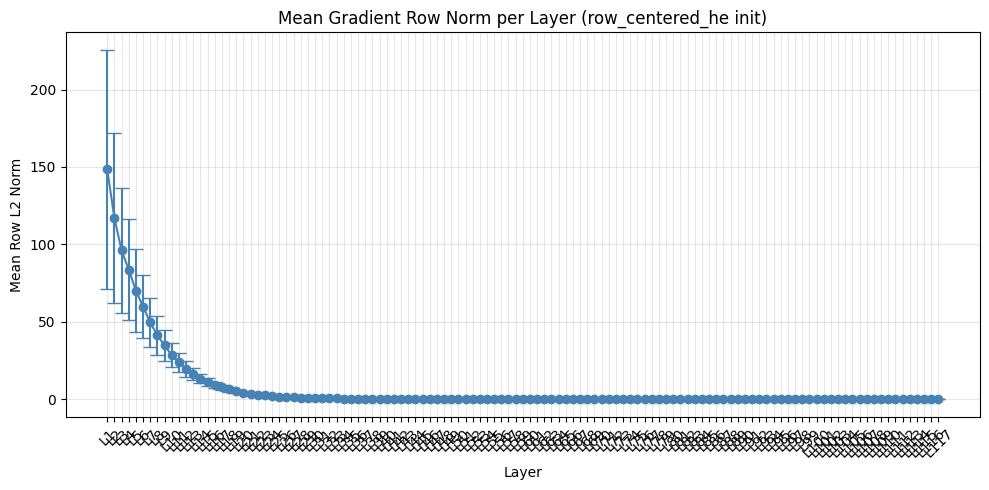

In [55]:
# Plot mean row norm per layer
fig = plot_row_norm_per_layer(results, exclude_output_layer=True)
plt.title(f"Mean Gradient Row Norm per Layer ({INIT_STRATEGY} init)")
plt.show()

In [ ]:
# Plot activation zero statistics
fig = plot_activation_zero_stats(results)
plt.suptitle(f"Activation Zero Analysis ({INIT_STRATEGY} init)", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Compare Initialization Strategies

Run the same experiment with different initialization strategies.

**Important distinction:**
- **Gradient entry zeros**: Individual entries in ∂L/∂W that are exactly 0
- **Activation zeros**: Post-ReLU activations that are 0 (~50% due to ReLU's nature)
- **Truly inactive neurons**: Neurons that output 0 for ALL samples (neuron death)

### Strategies being compared:

**Baseline:**
- `he`: Standard He initialization (may have dead neurons)
- `row_centered_he`: Row-centered He (no dead neurons, but gradient trap)
- `row_centered_he_var_adj`: Row-centered + variance restored

**Experimental (to address gradient trap):**
- `partial_centered_he`: Soft centering with α=0.5 (partial constraint)
- `orthogonal_he`: QR orthogonal (rows orthogonal but don't sum to zero)
- `centered_with_dc_he`: Full centering + DC component (breaks zero-sum)

In [ ]:
# Strategies to compare - including the new experimental options
STRATEGIES_TO_COMPARE = [
    "he",                      # Baseline: standard He
    "row_centered_he",         # Row-centered (gradient trap issue)
    "row_centered_he_var_adj", # Row-centered + variance adjustment
    "partial_centered_he",     # Option 1: Partial centering (alpha=0.5)
    "orthogonal_he",           # Option 2: QR orthogonal
    "centered_with_dc_he",     # Option 3: Centered + DC component
]

# Run comparison
comparison_results = compare_initializations(
    layer_sizes=LAYER_SIZES,
    init_strategies=STRATEGIES_TO_COMPARE,
    num_samples=NUM_SAMPLES,
    dataset=DATASET,
    seed=SEED
)

# Print detailed comparison results
print("=" * 70)
print("COMPARISON RESULTS")
print("=" * 70)

for strategy, result in comparison_results.items():
    # Gradient entry zeros (dead neurons cause entire rows to be zero)
    grad_zero_props = result.get_zero_gradient_proportions()
    avg_grad_zero = np.mean(list(grad_zero_props.values()))
    
    # Activation zeros (ReLU zeros out negative pre-activations)
    act_zero_props = result.get_activation_zero_proportions()
    avg_act_zero = np.mean(list(act_zero_props.values()))
    
    # Truly inactive neurons (zero for ALL samples = dead neurons)
    inactive_props = result.get_truly_inactive_proportions()
    avg_inactive = np.mean(list(inactive_props.values()))
    
    print(f"\n{strategy.upper()}:")
    print(f"  Gradient entry zeros:   {avg_grad_zero:.1%}  (entire rows become 0 when neurons die)")
    print(f"  Activation zeros:       {avg_act_zero:.1%}  (expected ~50% due to ReLU)")
    print(f"  Truly inactive neurons: {avg_inactive:.1%}  (zero for ALL samples = dead)")

print("\n" + "=" * 70)

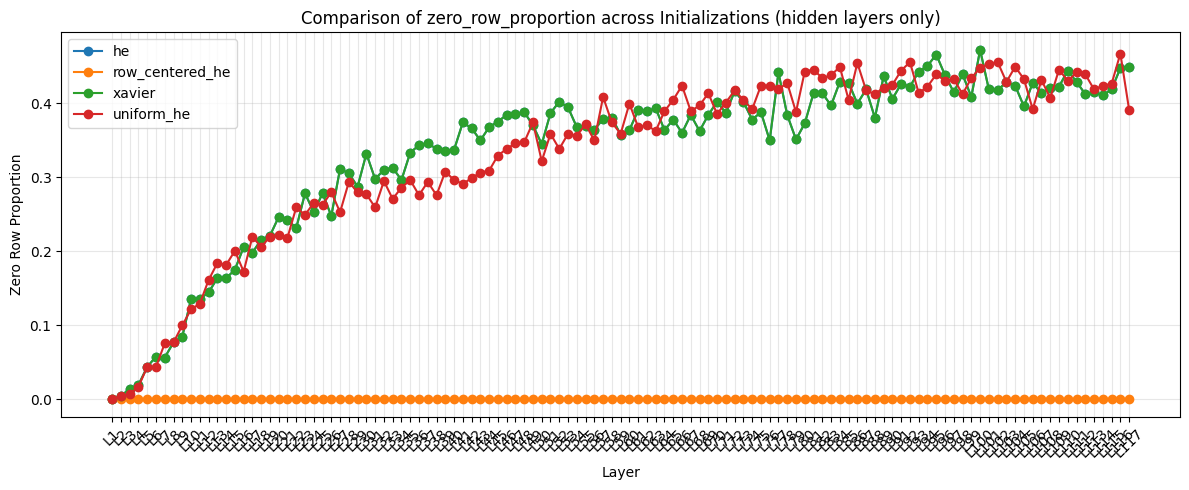

In [59]:
# Compare zero gradient proportions (excluding output layer for better visualization)
fig = compare_initializations_plot(
    comparison_results,
    metric="zero_row_proportion",
    exclude_output_layer=True  # Output layer has much larger gradients
)
plt.show()

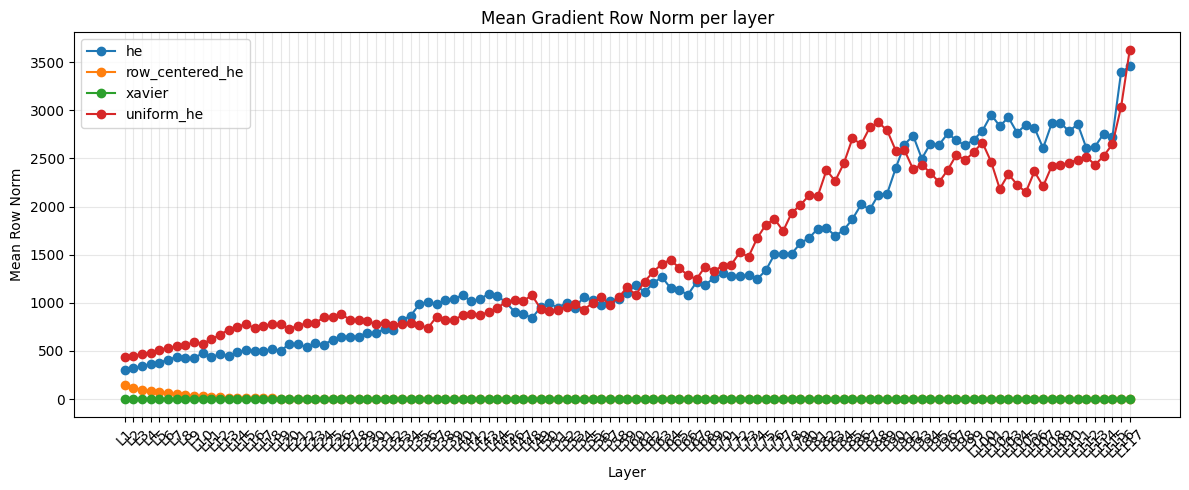

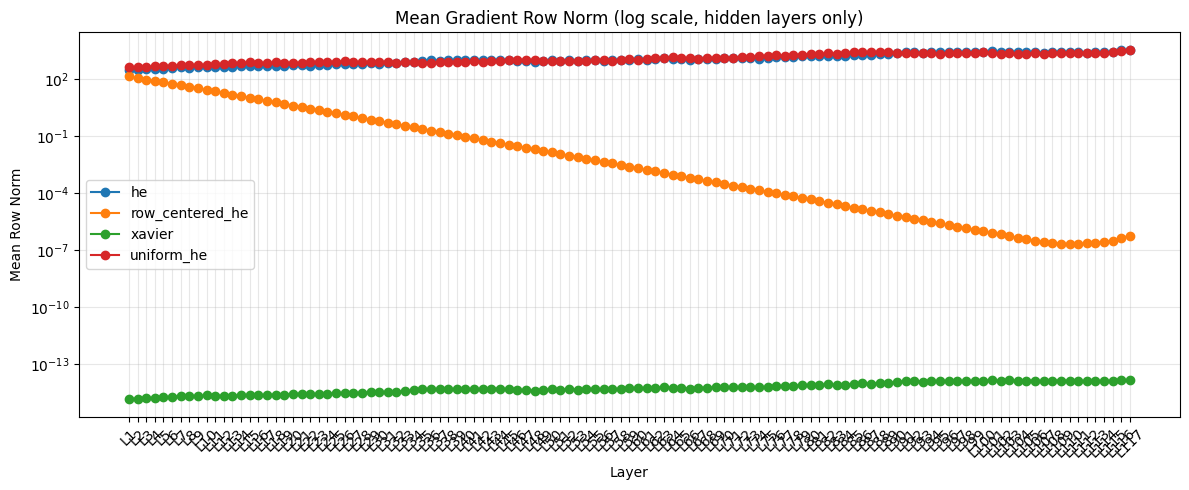

In [61]:
# Compare mean row norms (excluding output layer which dominates y-axis)
fig = compare_initializations_plot(
    comparison_results,
    metric="mean_row_norm",
    exclude_output_layer=True
)
plt.title("Mean Gradient Row Norm per layer")
plt.show()

# Also show with log scale for better comparison
fig = compare_initializations_plot(
    comparison_results,
    metric="mean_row_norm",
    exclude_output_layer=True,
    use_log_scale=True
)
plt.title("Mean Gradient Row Norm (log scale, hidden layers only)")
plt.show()

## 3. Deep Network Analysis (100+ layers)

Analyze gradient flow in very deep networks.

In [62]:
# Deep network configuration
N_HIDDEN_LAYERS = 100
WIDTH_RANGE = (100, 1000)  # Random widths between 100 and 1000

# Create deep network
deep_net = create_deep_network(
    input_dim=784,
    output_dim=1,
    num_hidden_layers=N_HIDDEN_LAYERS,
    hidden_widths="random",
    width_range=WIDTH_RANGE,
    init_strategy="row_centered_he",
    seed=SEED
)

print(f"Deep network created:")
print(f"  Number of layers: {deep_net.num_layers}")
print(f"  Architecture: {deep_net.layer_sizes[:5]}...{deep_net.layer_sizes[-3:]}")
print(f"  Total parameters: {sum(p.numel() for p in deep_net.parameters()):,}")

Deep network created:
  Number of layers: 101
  Architecture: [784, 202, 535, 960, 370]...[915, 370, 1]
  Total parameters: 29,040,824


In [66]:
# Run deep network experiment
deep_network_config = NetworkConfig(
    layer_sizes=deep_net.layer_sizes,
    init_strategy="row_centered_he"
)

deep_experiment = GradientExperiment(exp_config, deep_network_config, grad_config)
deep_results = deep_experiment.run()

print(f"\nDeep Network Results:")
print(f"  Loss: {deep_results.loss_value:.4e}")


Deep Network Results:
  Loss: 5.7146e+04


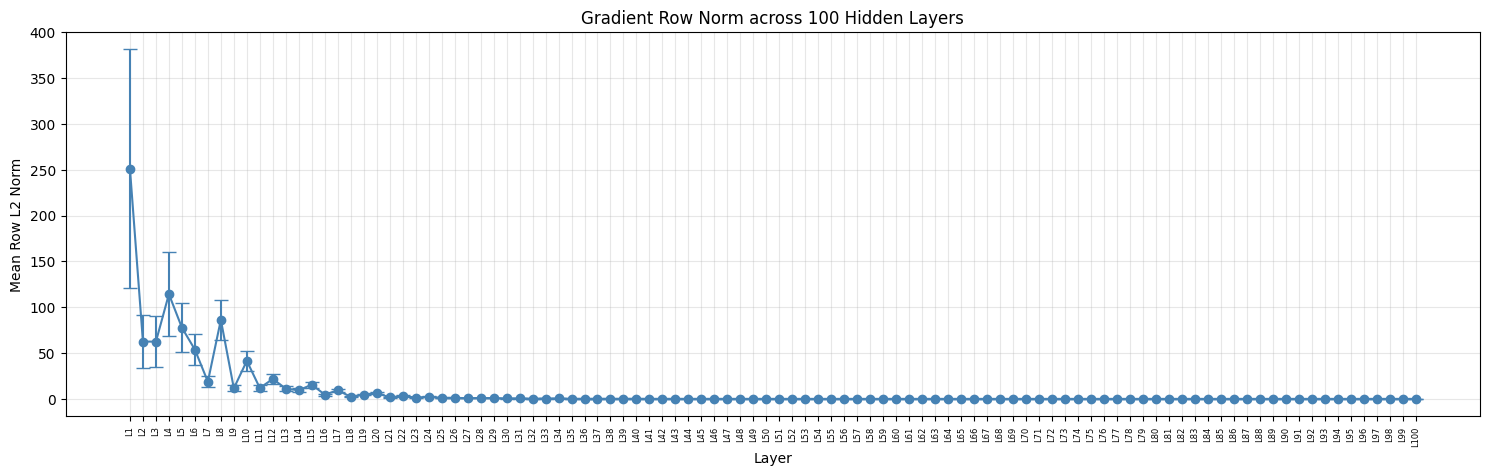

In [67]:
# Plot mean row norm across all layers
fig = plot_row_norm_per_layer(deep_results, figsize=(15, 5),exclude_output_layer=True)
plt.title(f"Gradient Row Norm across {N_HIDDEN_LAYERS} Hidden Layers")
plt.xticks(rotation=90, fontsize=6)
plt.show()

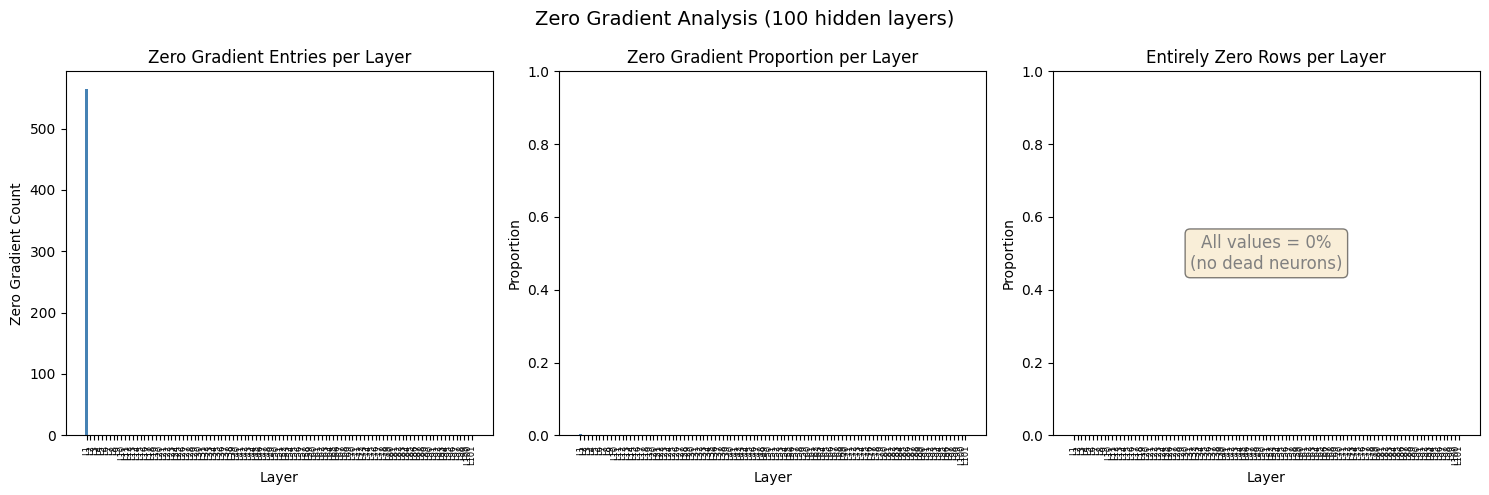

In [68]:
# Plot zero gradient statistics
fig = plot_zero_gradient_stats(deep_results, figsize=(15, 5))
for ax in fig.axes:
    ax.tick_params(axis='x', rotation=90, labelsize=6)
plt.suptitle(f"Zero Gradient Analysis ({N_HIDDEN_LAYERS} hidden layers)", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Custom Variance Experiments

Compare different variance scales (2/d, 2.5/d, 4/d).

In [ ]:
# Variance scales to test
VARIANCE_SCALES = [2.0, 2.5, 3.0, 4.0]  # multiplier for 1/d
d = LAYER_SIZES[0]  # input dimension

variance_results = {}

for scale in VARIANCE_SCALES:
    variance = scale / d
    exp_config.setup_seeds()  # Reset for fair comparison
    
    net_config = NetworkConfig(
        layer_sizes=LAYER_SIZES,
        init_strategy="custom_variance",
        weight_variance=variance
    )
    
    experiment = GradientExperiment(exp_config, net_config, grad_config)
    result = experiment.run()
    variance_results[f"{scale}/d"] = result
    
    print(f"Variance {scale}/d: loss = {result.loss_value:.4e}")

In [ ]:
# Compare variance scales
fig = compare_initializations_plot(
    variance_results,
    metric="zero_proportion"
)
plt.title("Zero Gradient Proportion by Variance Scale")
plt.show()

In [ ]:
fig = compare_initializations_plot(
    variance_results,
    metric="mean_row_norm"
)
plt.title("Mean Gradient Row Norm by Variance Scale")
plt.show()

## Summary

Key findings from this analysis:

1. **Gradient sparsity**: Proportion of zero gradients varies by initialization
2. **Row norms**: How gradient magnitude distributes across layers
3. **Deep networks**: Gradient flow characteristics in 100+ layer networks
4. **Variance scaling**: Effect of different variance scales on gradient statistics